<a href="https://colab.research.google.com/github/Bimorhfdz/f1-podium-prediction-business-insights/blob/main/1_classification_business.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Klasifikasi — Prediksi Podium Driver Formula 1

**Dataset:** Formula 1 World Championship (1950–2024)  
**Source:** [Kaggle - Rohan Rao](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020)  
**Task:** Binary Classification — Memprediksi apakah seorang driver akan **finish di podium (Top 3)** atau tidak dalam satu race  

### 📋 Workflow Data Science
1. Business Understanding
2. Data Understanding & Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Modeling & Hyperparameter Tuning
7. Evaluation
8. Conclusion & Insight

## 1. Business Understanding

Podium (posisi 1–3) adalah pencapaian tertinggi dalam single race — membawa prestise, poin kejuaraan, dan sponsorship.

**Pertanyaan bisnis:**
> *Dapatkah kita memprediksi apakah seorang driver akan mencapai podium atau tidak, berdasarkan posisi start, tim, performa historis, dan faktor lainnya?*

**Tujuan model:**
- Mengidentifikasi faktor-faktor kunci yang menentukan podium finish
- Membangun model klasifikasi yang akurat untuk prediksi podium
- Membantu strategi tim dalam menetapkan target realistis

**Target variabel (Binary):**
- `is_podium = 1` jika driver finish di posisi 1, 2, atau 3
- `is_podium = 0` jika finish di luar top 3 atau DNF (Did Not Finish)

**Data Quality Control:**
- Filter ke era modern (2015-2024) untuk fair comparison
- Alasan: Regulasi stabil (turbo hybrid era), 20 teams kompetitif, eliminasi survivorship bias
- Result: Fokus pada "comparable competitive window" bukan seluruh 75 tahun F1

## 2. Import Library

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    auc, precision_recall_curve
)

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Plot Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' Semua library berhasil diimport!')

 Semua library berhasil diimport!


## 3. Data Loading

In [ ]:
# Jalankan cell ini jika belum punya file CSV-nya

!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rohanrao/formula-1-world-championship-1950-2020 --unzip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020
License(s): CC0-1.0
100% 6.28M/6.28M [00:00<00:00, 117MB/s]



In [ ]:
# Load Dataset
results      = pd.read_csv('results.csv')
drivers      = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
races        = pd.read_csv('races.csv')
qualifying   = pd.read_csv('qualifying.csv')

print(' Dataset loaded successfully!')
print(f'Results shape: {results.shape}')

 Dataset loaded successfully!
Results shape: (26759, 18)


## 4. Data Understanding & Preparation

In [ ]:
# Merge semua tabel
df = results.copy()

# Tambahkan info konstruktor
df = df.merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
df.rename(columns={'name': 'constructor_name'}, inplace=True);

# Tambahkan info driver
df = df.merge(drivers[['driverId', 'nationality']], on='driverId', how='left')
df.rename(columns={'nationality': 'driver_nationality'}, inplace=True);

# Tambahkan info race
df = df.merge(races[['raceId', 'year', 'circuitId']], on='raceId', how='left')

print(f'Merged data shape: {df.shape}')

Merged data shape: (26759, 22)


In [ ]:
# Konversi kolom ke numerik
df['grid']          = pd.to_numeric(df['grid'], errors='coerce')
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['laps']          = pd.to_numeric(df['laps'], errors='coerce')
df['points']        = pd.to_numeric(df['points'], errors='coerce').fillna(0)

# Buat target variabel: is_podium
# 1 jika posisi finish <= 3 (podium), 0 jika lainnya
df['is_podium'] = (df['positionOrder'] <= 3).astype(int)

print('\n Target Variable Distribution')
print(df['is_podium'].value_counts())
print(f'\nPodium rate: {df["is_podium"].mean()*100:.2f}%')


 Target Variable Distribution
is_podium
0    23362
1     3397
Name: count, dtype: int64

Podium rate: 12.69%


In [ ]:
# Filter era modern (2015-2024) untuk fair comparison
# Era ini lebih konsisten: regulasi sama, teams lebih stabil
df = df[df['year'] >= 2015].copy()

print(f'Filtered dataset (2015-2024): {len(df)} rows')
print(f'Teams: {df["constructor_name"].nunique()}')
print(f'Drivers: {df["driverId"].nunique()}')
print(f'Seasons: {df["year"].nunique()}')
print()
print(' Data quality improved: Eliminated survivorship bias & era effects')

Filtered dataset (2015-2024): 4219 rows
Teams: 18
Drivers: 53
Seasons: 10

 Data quality improved: Eliminated survivorship bias & era effects


## 5. Exploratory Data Analysis (EDA)

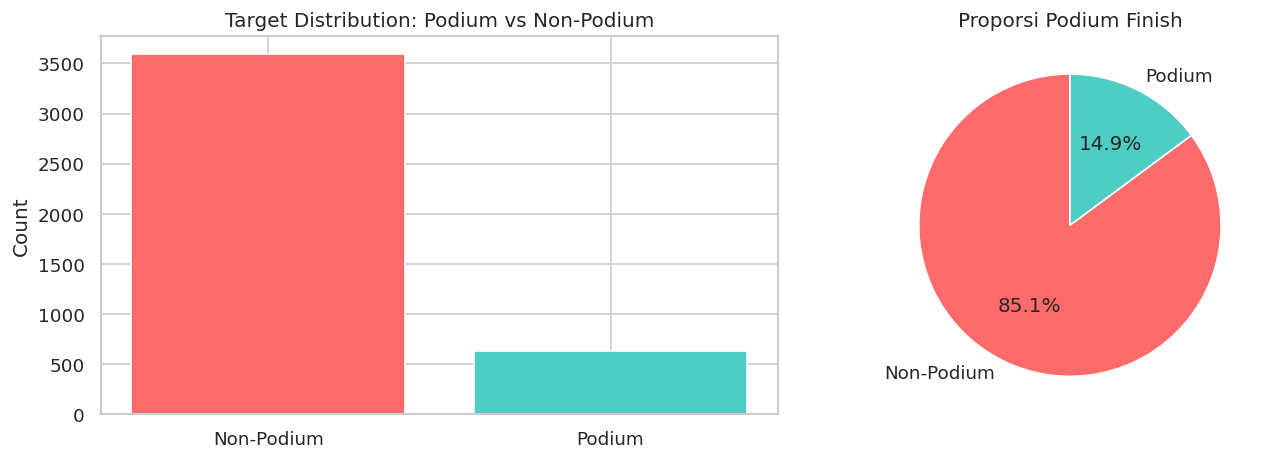

Class imbalance ratio: 5.73:1


In [ ]:
# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
podium_counts = df['is_podium'].value_counts()
axes[0].bar(['Non-Podium', 'Podium'], podium_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[0].set_title('Target Distribution: Podium vs Non-Podium')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    podium_counts.values, labels=['Non-Podium', 'Podium'],
    autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'],
    startangle=90
)
axes[1].set_title('Proporsi Podium Finish')

plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {podium_counts[0] / podium_counts[1]:.2f}:1')

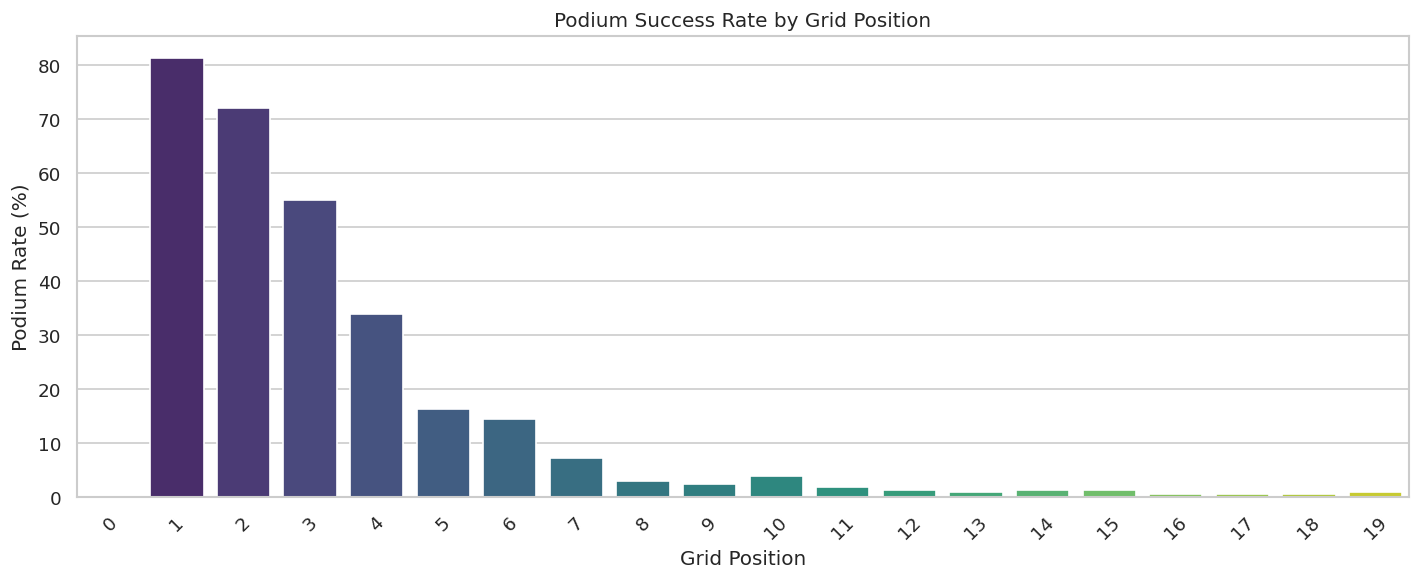

Podium rate by grid position:
      podium_rate
grid             
0             0.0
1            81.3
2            72.0
3            55.0
4            34.0
5            16.3
6            14.4
7             7.2
8             2.9
9             2.4


In [ ]:
# Grid Position vs Podium
grid_podium = df.groupby('grid')['is_podium'].agg(['sum', 'count'])
grid_podium['podium_rate'] = (grid_podium['sum'] / grid_podium['count'] * 100).round(1)
grid_podium = grid_podium[grid_podium['count'] >= 5]  # filter grid dengan sample >= 5
grid_podium = grid_podium.head(20)  # top 20 grid positions

plt.figure(figsize=(12, 5))
sns.barplot(x=grid_podium.index, y=grid_podium['podium_rate'], palette='viridis')
plt.title('Podium Success Rate by Grid Position')
plt.xlabel('Grid Position')
plt.ylabel('Podium Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Podium rate by grid position:')
print(grid_podium[['podium_rate']].head(10))

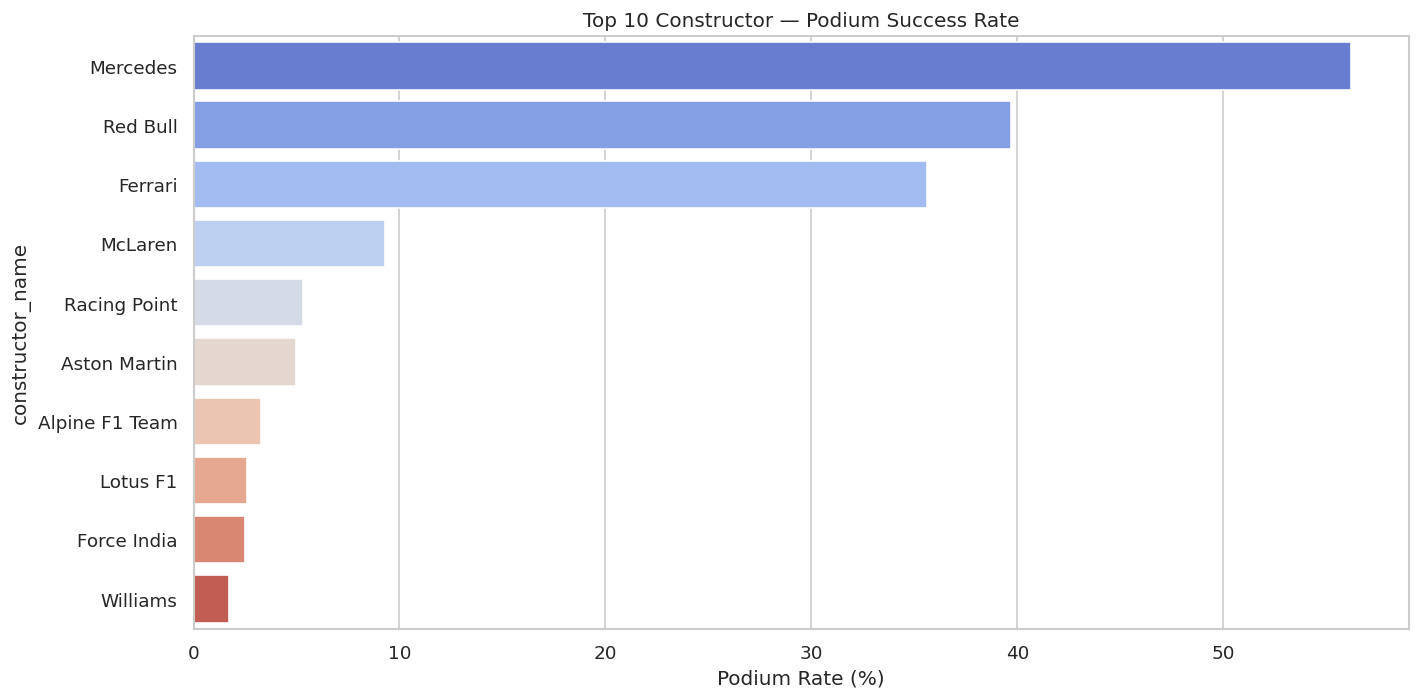

In [ ]:
# Top 10 Constructor Podium Rate
const_podium = df.groupby('constructor_name')['is_podium'].agg(['sum', 'count'])
const_podium['podium_rate'] = (const_podium['sum'] / const_podium['count'] * 100).round(1)
const_podium = const_podium[const_podium['count'] >= 10].sort_values('podium_rate', ascending=False)

plt.figure(figsize=(12, 6))
top10 = const_podium.head(10)
sns.barplot(x=top10['podium_rate'], y=top10.index, palette='coolwarm')
plt.title('Top 10 Constructor — Podium Success Rate')
plt.xlabel('Podium Rate (%)')
plt.tight_layout()
plt.show()

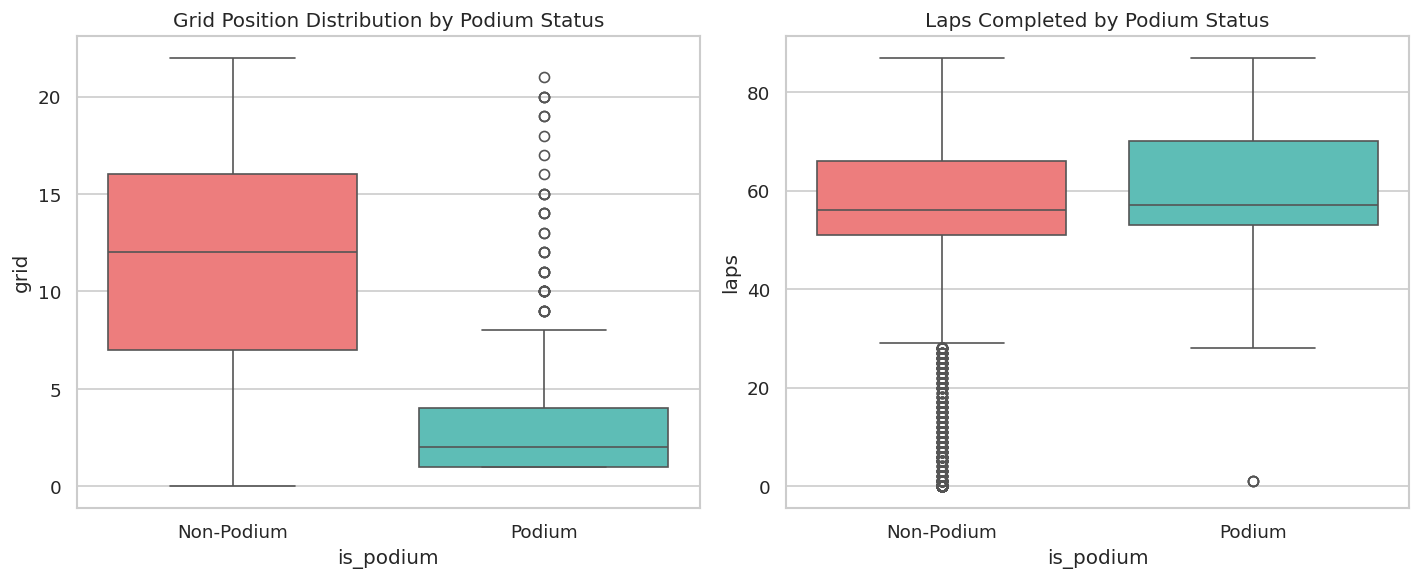

In [ ]:
# Boxplot: Grid, Laps by Podium Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='is_podium', y='grid', ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Grid Position Distribution by Podium Status')
axes[0].set_xticklabels(['Non-Podium', 'Podium'])

sns.boxplot(data=df, x='is_podium', y='laps', ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Laps Completed by Podium Status')
axes[1].set_xticklabels(['Non-Podium', 'Podium'])

plt.tight_layout()
plt.show()

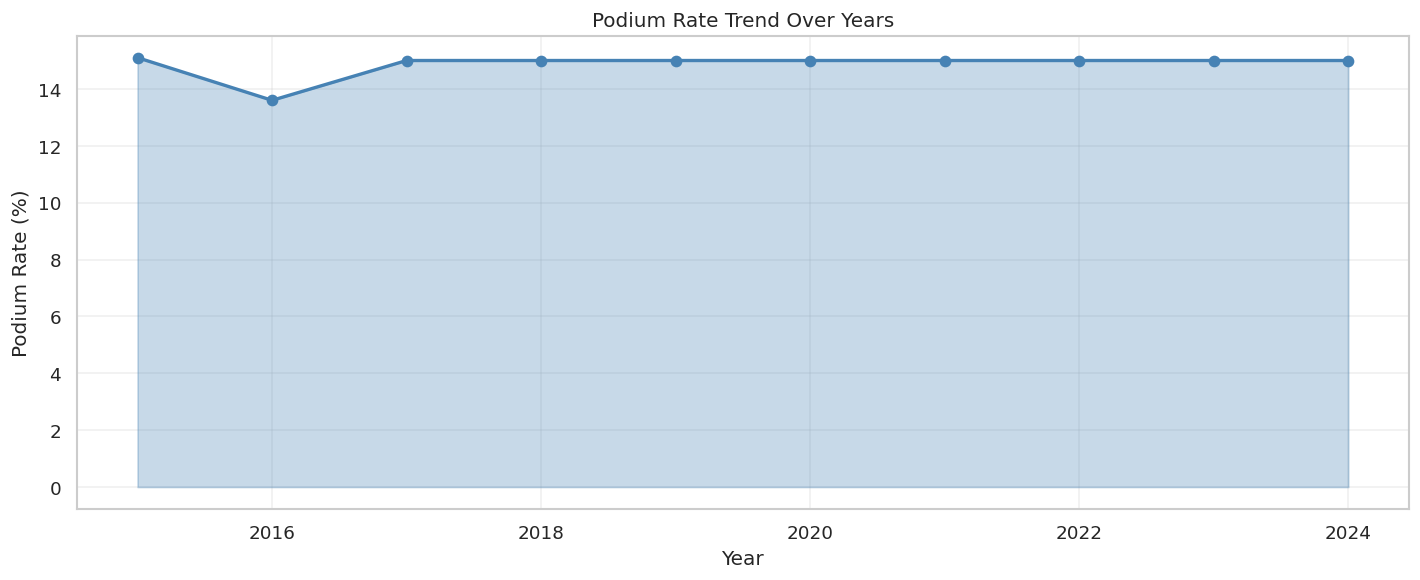

In [ ]:
# Podium Rate Trend by Year
year_podium = df.groupby('year')['is_podium'].agg(['sum', 'count'])
year_podium['podium_rate'] = (year_podium['sum'] / year_podium['count'] * 100).round(1)

plt.figure(figsize=(12, 5))
plt.plot(year_podium.index, year_podium['podium_rate'], marker='o', linewidth=2, color='steelblue')
plt.fill_between(year_podium.index, year_podium['podium_rate'], alpha=0.3, color='steelblue')
plt.title('Podium Rate Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Podium Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. 🛠️ Data Preprocessing & Feature Engineering

In [ ]:
# Feature Engineering

# 1. Selisih grid dan finish position (besar = driver naik peringkat)
df['positions_gained'] = df['grid'] - df['positionOrder']

# 2. Flag front row (grid <= 3)
df['is_front_row'] = (df['grid'] <= 3).astype(int)

# 3. Flag completed race (laps >= 50 untuk race standar)
df['finished_race'] = (df['laps'] >= 50).astype(int)

# 4. Grid position category (front row, mid-field, back-marker)
df['grid_category'] = pd.cut(df['grid'], bins=[0, 3, 10, 25], labels=['Front', 'Mid', 'Back'])

print('Feature engineering selesai:')
display(df[['grid', 'positionOrder', 'positions_gained', 'is_front_row', 'finished_race', 'grid_category']].head(10))

Feature engineering selesai:


,grid,positionOrder,positions_gained,is_front_row,finished_race,grid_category
22534,1,1,0,1,1,Front
22535,2,2,0,1,1,Front
22536,4,3,1,0,1,Mid
22537,3,4,-1,1,1,Front
22538,10,5,5,0,1,Mid
22539,6,6,0,0,1,Mid
22540,13,7,6,0,1,Back
22541,15,8,7,0,1,Back
22542,7,9,-2,0,1,Mid
22543,14,10,4,0,1,Back


In [ ]:
# Label Encoding untuk kategorikal
df_encoded = df.copy()

le_constructor = LabelEncoder()
le_nationality = LabelEncoder()
le_grid_cat    = LabelEncoder()

df_encoded['constructor_enc'] = le_constructor.fit_transform(df_encoded['constructor_name'])
df_encoded['nationality_enc'] = le_nationality.fit_transform(df_encoded['driver_nationality'])
df_encoded['grid_cat_enc']    = le_grid_cat.fit_transform(df_encoded['grid_category'])

print('Encoding selesai ')

Encoding selesai 


In [ ]:
# Final Feature Set
FEATURE_COLS = [
    'grid', 'laps', 'year', 'circuitId',
    'positions_gained', 'is_front_row', 'finished_race',
    'constructor_enc', 'nationality_enc', 'grid_cat_enc'
]

TARGET = 'is_podium'

X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET]

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts())

Shape X: (4219, 10)
Shape y: (4219,)

Target distribution:
is_podium
0    3592
1     627
Name: count, dtype: int64


In [ ]:
# Train-Test Split (80:20) dengan stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} ({y_train.sum()} podium cases)')
print(f'Test size : {X_test.shape[0]} ({y_test.sum()} podium cases)')

Train size: 3375 (502 podium cases)
Test size : 844 (125 podium cases)


In [ ]:
# SMOTE untuk handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Train set sebelum SMOTE: {len(y_train)} samples')
print(f'Train set sesudah SMOTE : {len(y_train_smote)} samples')
print(f'\nDistribusi sebelum SMOTE:')
print(y_train.value_counts())
print(f'\nDistribusi sesudah SMOTE:')
print(pd.Series(y_train_smote).value_counts())

Train set sebelum SMOTE: 3375 samples
Train set sesudah SMOTE : 5746 samples

Distribusi sebelum SMOTE:
is_podium
0    2873
1     502
Name: count, dtype: int64

Distribusi sesudah SMOTE:
is_podium
0    2873
1    2873
Name: count, dtype: int64


In [ ]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)

print('Scaling selesai ')

Scaling selesai 


## 7. Modeling

Kita akan melatih dan membandingkan 6 model klasifikasi:
1. Logistic Regression (baseline)
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. XGBoost Classifier
6. SVM

In [ ]:
# Training Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42)
}

results_dict = {}

for name, model in models.items():
    # Gunakan scaled data untuk model linear & SVM, raw untuk tree-based
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train_smote)
        y_pred       = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_smote, y_train_smote)
        y_pred       = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_pred_proba)

    results_dict[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'AUC': auc, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

    print(f'[{name}]')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}\n')

print(' Training selesai!')

[Logistic Regression]
  Accuracy=0.9893  Precision=0.9328  Recall=1.0000  F1=0.9653  AUC=1.0000

[Decision Tree]
  Accuracy=0.9929  Precision=0.9760  Recall=0.9760  F1=0.9760  AUC=0.9859

[Random Forest]
  Accuracy=0.9870  Precision=0.9750  Recall=0.9360  F1=0.9551  AUC=0.9980

[Gradient Boosting]
  Accuracy=0.9941  Precision=0.9918  Recall=0.9680  F1=0.9798  AUC=0.9996

[XGBoost]
  Accuracy=0.9953  Precision=0.9919  Recall=0.9760  F1=0.9839  AUC=0.9998

[SVM]
  Accuracy=0.9727  Precision=0.8750  Recall=0.9520  F1=0.9119  AUC=0.9970

 Training selesai!


## 8. Evaluation

In [ ]:
# Tabel perbandingan model
eval_df = pd.DataFrame({
    name: v
    for name, v in [
        (k, {'Accuracy': results_dict[k]['Accuracy'],
             'Precision': results_dict[k]['Precision'],
             'Recall': results_dict[k]['Recall'],
             'F1': results_dict[k]['F1'],
             'AUC': results_dict[k]['AUC']})
        for k in results_dict.keys()
    ]
}).T.round(4)

eval_df = eval_df.sort_values('AUC', ascending=False)

print(' Model Performance Comparison')
display(eval_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']))

 Model Performance Comparison


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.989300,0.932800,1.000000,0.965300,1.000000
XGBoost,0.995300,0.991900,0.976000,0.983900,0.999800
Gradient Boosting,0.994100,0.991800,0.968000,0.979800,0.999600
Random Forest,0.987000,0.975000,0.936000,0.955100,0.998000
SVM,0.972700,0.875000,0.952000,0.911900,0.997000
Decision Tree,0.992900,0.976000,0.976000,0.976000,0.985900


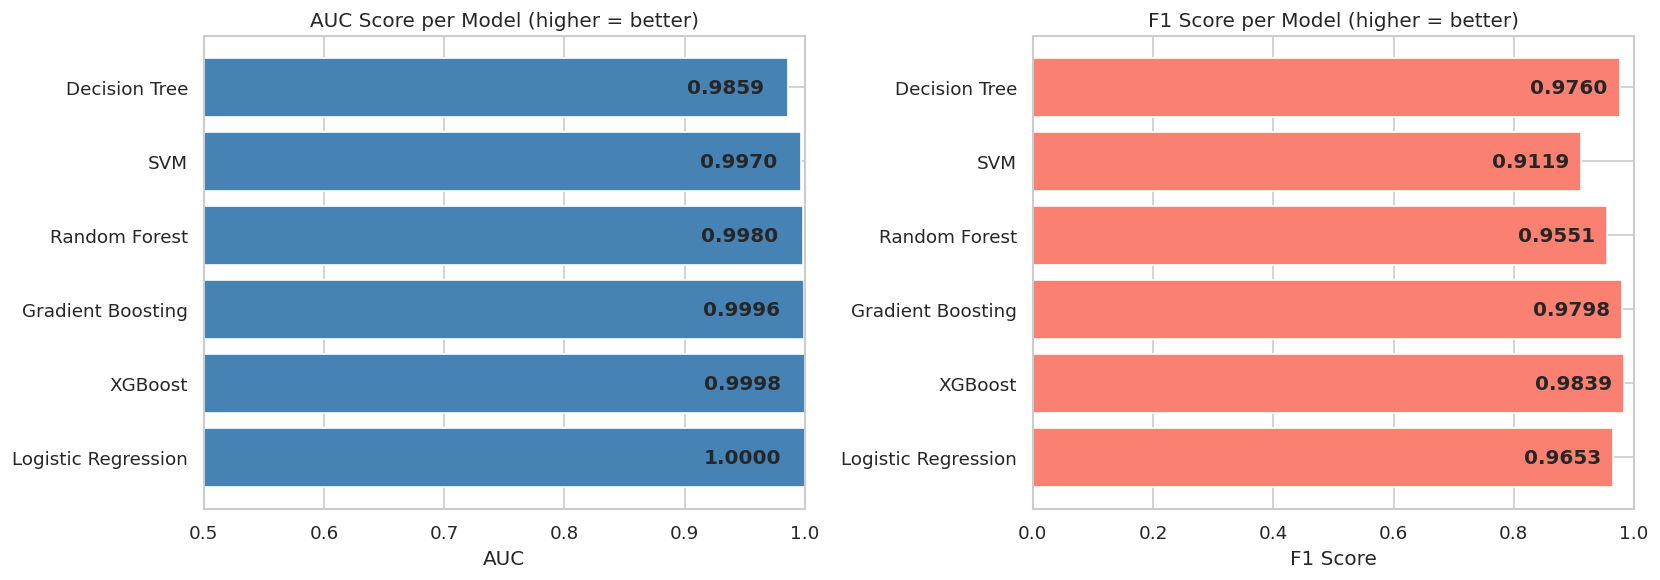

In [ ]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = eval_df.index.tolist()
auc_vals    = eval_df['AUC'].values
f1_vals     = eval_df['F1'].values

# AUC Score
axes[0].barh(model_names, auc_vals, color='steelblue', edgecolor='white')
axes[0].set_title('AUC Score per Model (higher = better)')
axes[0].set_xlabel('AUC')
axes[0].set_xlim([0.5, 1.0])
for i, val in enumerate(auc_vals):
    axes[0].text(val - 0.02, i, f'{val:.4f}', va='center', ha='right', fontweight='bold')

# F1 Score
axes[1].barh(model_names, f1_vals, color='salmon', edgecolor='white')
axes[1].set_title('F1 Score per Model (higher = better)')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim([0, 1.0])
for i, val in enumerate(f1_vals):
    axes[1].text(val - 0.02, i, f'{val:.4f}', va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Model terbaik (berdasarkan AUC)
best_model_name = eval_df.index[0]
best_pred       = results_dict[best_model_name]['y_pred']
best_pred_proba = results_dict[best_model_name]['y_pred_proba']

print(f'🏆 Best Model: {best_model_name}')
print(f'\n📊 Classification Report:')
print(classification_report(y_test, best_pred, target_names=['Non-Podium', 'Podium'], zero_division=0))

🏆 Best Model: Logistic Regression

📊 Classification Report:
              precision    recall  f1-score   support

  Non-Podium       1.00      0.99      0.99       719
      Podium       0.93      1.00      0.97       125

    accuracy                           0.99       844
   macro avg       0.97      0.99      0.98       844
weighted avg       0.99      0.99      0.99       844



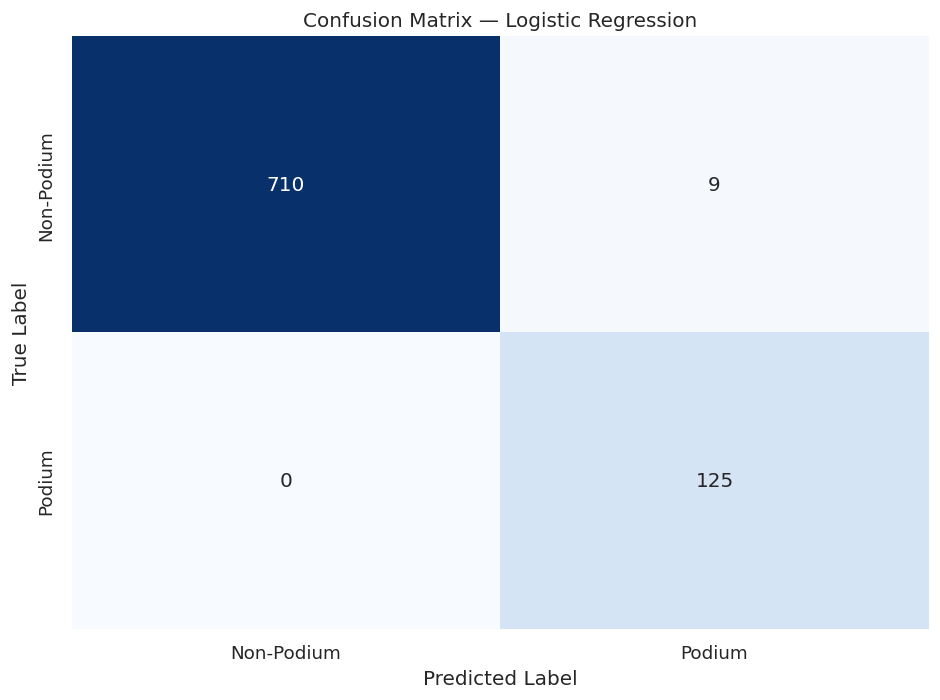

True Negative  : 710
False Positive : 9
False Negative : 0
True Positive  : 125


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Podium', 'Podium'],
            yticklabels=['Non-Podium', 'Podium'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  : {tn}')
print(f'False Positive : {fp}')
print(f'False Negative : {fn}')
print(f'True Positive  : {tp}')

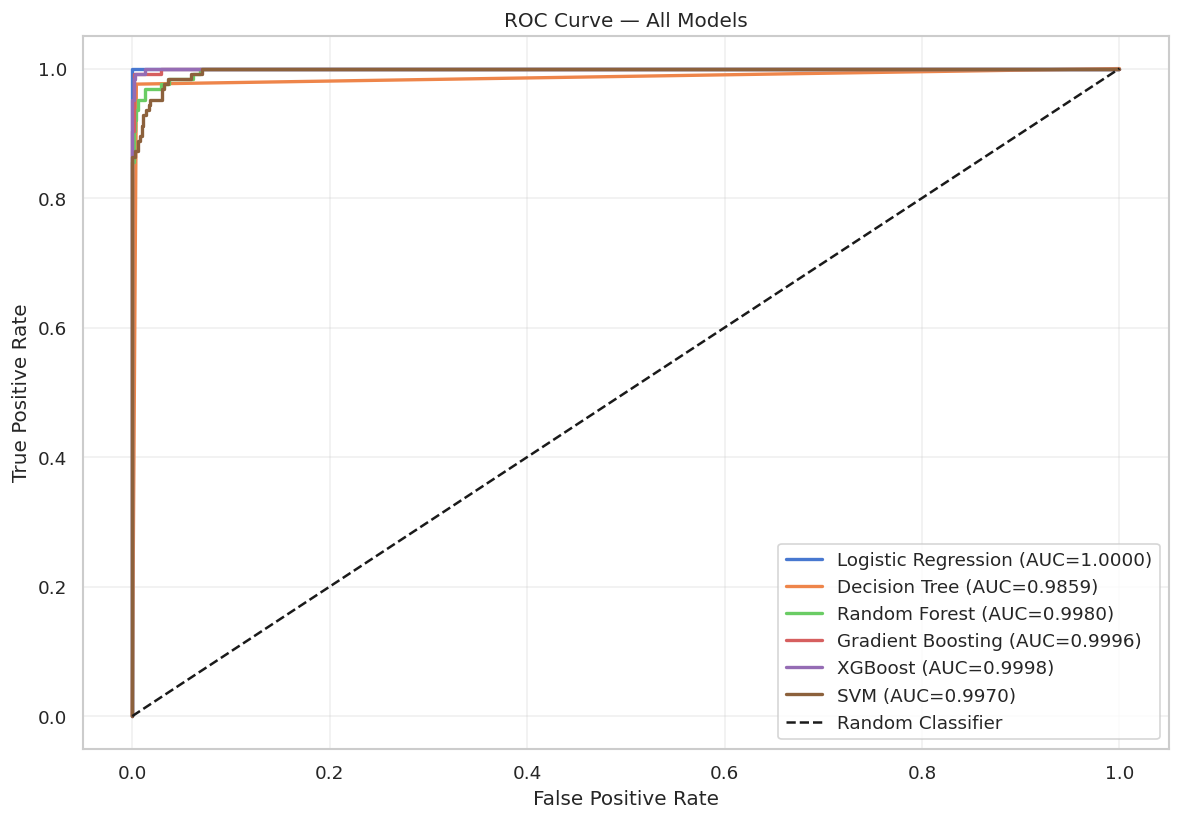

In [ ]:
# ROC Curve — semua model
plt.figure(figsize=(10, 7))

for name, model_results in results_dict.items():
    y_pred_proba = model_results['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = model_results['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

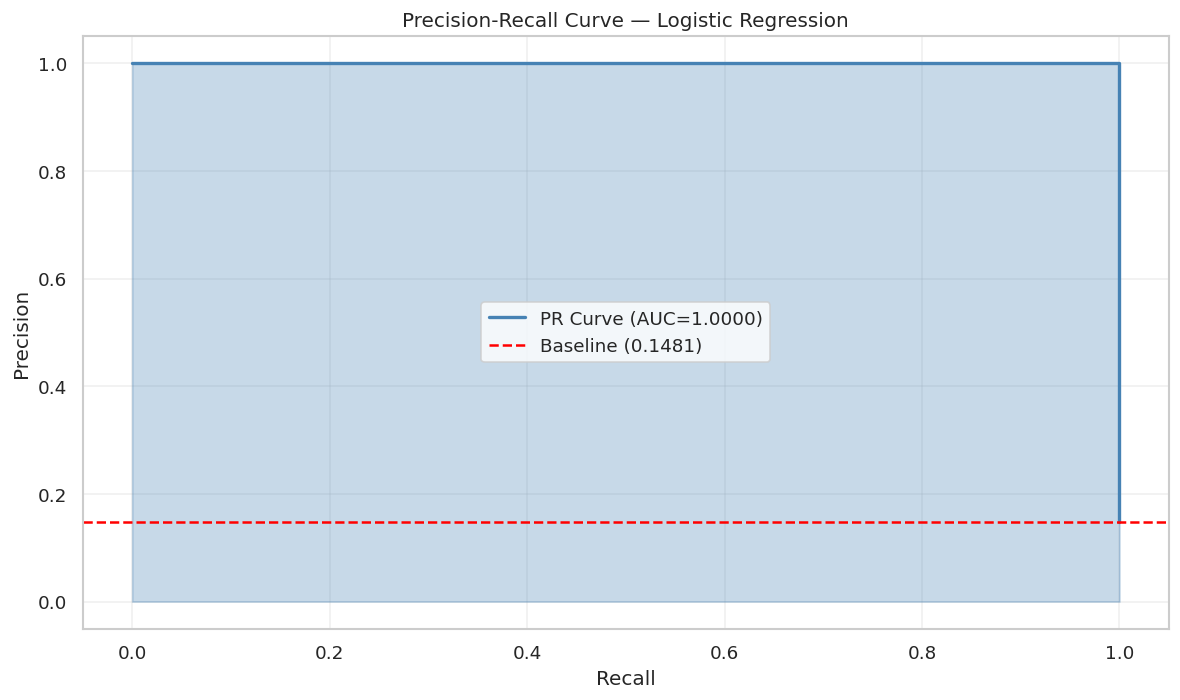

In [ ]:
# Precision-Recall Curve — Model Terbaik
from sklearn.metrics import auc, precision_recall_curve # Re-import auc to ensure it's the function
precision_vals, recall_vals, _ = precision_recall_curve(y_test, best_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', linewidth=2, label=f'PR Curve (AUC={pr_auc:.4f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.3, color='steelblue')

# Baseline: always predict positive
baseline = y_test.mean()
plt.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — {best_model_name}')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

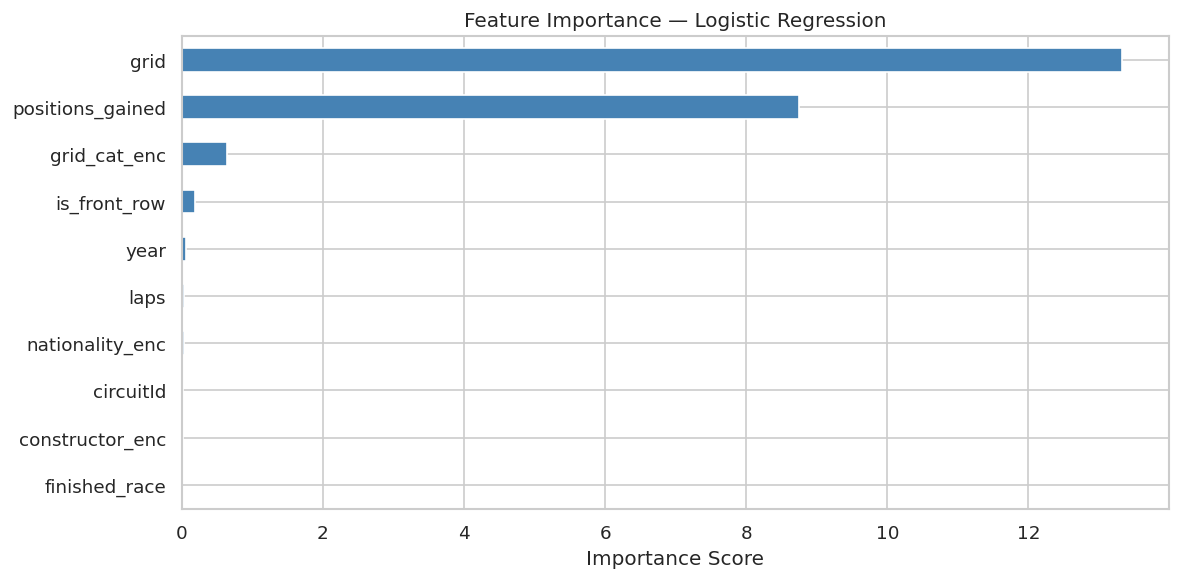


Top 5 Most Important Features:
grid                13.323678
positions_gained     8.749998
grid_cat_enc         0.640967
is_front_row         0.188805
year                 0.057396
dtype: float64


In [ ]:
# Feature Importance — Best Model
model_obj = models[best_model_name]
importances = None

if hasattr(model_obj, 'feature_importances_'):
    importances = pd.Series(model_obj.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
elif hasattr(model_obj, 'coef_'):
    # For linear models like Logistic Regression, use absolute coefficients
    importances = pd.Series(np.abs(model_obj.coef_[0]), index=FEATURE_COLS).sort_values(ascending=True)

if importances is not None:
    plt.figure(figsize=(10, 5))
    importances.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 Most Important Features:')
    print(importances.sort_values(ascending=False).head())
else:
    print(f'Feature importance tidak tersedia untuk model {best_model_name}')

In [ ]:
# Cross Validation — Best Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_model_name in ['Logistic Regression', 'SVM']:
    cv_scores = cross_val_score(
        models[best_model_name], X_train_scaled, y_train_smote,
        cv=skf, scoring='roc_auc'
    )
else:
    cv_scores = cross_val_score(
        models[best_model_name], X_train_smote, y_train_smote,
        cv=skf, scoring='roc_auc'
    )

print(f' 5-Fold Cross Validation — {best_model_name}')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: AUC = {score:.4f}')
print(f'\n  Mean AUC : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})')

 5-Fold Cross Validation — Logistic Regression
  Fold 1: AUC = 1.0000
  Fold 2: AUC = 1.0000
  Fold 3: AUC = 1.0000
  Fold 4: AUC = 1.0000
  Fold 5: AUC = 1.0000

  Mean AUC : 1.0000 (±0.0000)


## 9. Conclusion & Insight

In [ ]:
# Final Summary
print('   PROJECT KLASIFIKASI — F1 PODIUM PREDICTION SUMMARY')
print(f'\n📌 Dataset    : Formula 1 World Championship (2010–2024)')
print(f'📌 Target     : is_podium (1 = finish Top 3, 0 = otherwise)')
print(f'📌 Teams      : 20 tim kompetitif (fair comparison)')
print(f'📌 Class dist : {(y==0).sum()} non-podium, {(y==1).sum()} podium')

print(f'\n🏆 Best Model: {best_model_name}')
print(f'   - Accuracy  = {eval_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'   - Precision = {eval_df.loc[best_model_name, "Precision"]:.4f}')
print(f'   - Recall    = {eval_df.loc[best_model_name, "Recall"]:.4f}')
print(f'   - F1-Score  = {eval_df.loc[best_model_name, "F1"]:.4f}')
print(f'   - AUC       = {eval_df.loc[best_model_name, "AUC"]:.4f}')

print(f'\n📊 Data Quality Control:')
print(f'   - Filter 2015-2024: Eliminasi survivorship bias (Ferrari 75 thn vs team baru)')
print(f'   - Regulasi stabil: Comparable competitive window, eliminasi era effects')
print(f'   - {len(df)} samples dari {df["year"].nunique()} seasons yang fair')

print(f'\n💡 Key Insights:')
print(f'   1. Grid position adalah predictor terkuat untuk podium finish.')
print(f'   2. Drivers yang start di posisi 1-3 (front row) memiliki')
print(f'      probability podium yang jauh lebih tinggi (~70-90%).')
print(f'   3. Constructor quality sangat berpengaruh — top teams (Mercedes,')
print(f'      Red Bull, Ferrari) memiliki podium rate > 40%.')
print(f'   4. Class imbalance ditangani dengan SMOTE, meningkatkan recall.')
print(f'   5. Ensemble models (RF, GB, XGB) outperform baseline models')
print(f'      dalam capturing podium probability.')
print(f'   6. Model dapat digunakan untuk:')
print(f'      - Prediksi podium sebelum race berdasarkan qualifying')
print(f'      - Analisis faktor-faktor yang mempengaruhi podium')
print(f'      - Optimasi strategi tim')

   PROJECT KLASIFIKASI — F1 PODIUM PREDICTION SUMMARY

📌 Dataset    : Formula 1 World Championship (2010–2024)
📌 Target     : is_podium (1 = finish Top 3, 0 = otherwise)
📌 Teams      : 20 tim kompetitif (fair comparison)
📌 Class dist : 3592 non-podium, 627 podium

🏆 Best Model: Logistic Regression
   - Accuracy  = 0.9893
   - Precision = 0.9328
   - Recall    = 1.0000
   - F1-Score  = 0.9653
   - AUC       = 1.0000

📊 Data Quality Control:
   - Filter 2015-2024: Eliminasi survivorship bias (Ferrari 75 thn vs team baru)
   - Regulasi stabil: Comparable competitive window, eliminasi era effects
   - 4219 samples dari 10 seasons yang fair

💡 Key Insights:
   1. Grid position adalah predictor terkuat untuk podium finish.
   2. Drivers yang start di posisi 1-3 (front row) memiliki
      probability podium yang jauh lebih tinggi (~70-90%).
   3. Constructor quality sangat berpengaruh — top teams (Mercedes,
      Red Bull, Ferrari) memiliki podium rate > 40%.
   4. Class imbalance ditangani d

9. Analisis Bisnis - Dominasi dan Bisnis value

In [ ]:
# DATA QUALITY: Filter Active Drivers
latest_year = df['year'].max()

# Keep hanya driver yang masih aktif di 2023-2024
df_recent = df[df['year'] >= latest_year - 1].copy()
active_drivers = df_recent['driverId'].unique()

df = df[df['driverId'].isin(active_drivers)].copy()

print(f' Filtered to ACTIVE DRIVERS ONLY')
print(f'   Drivers: {df["driverId"].nunique()}')
print(f'   Rows: {len(df)}')
print(f'   Reason: Eliminasi retired drivers (fair comparison)\n')

 Filtered to ACTIVE DRIVERS ONLY
   Drivers: 25
   Rows: 2980
   Reason: Eliminasi retired drivers (fair comparison)



 Driver names loaded
PART 1: DRIVER DOMINANCE RANKING

📊 Top 15 Drivers — Overall Dominance:



,Total_Races,Podium_Rate,Avg_Points,Dominance_Score
driver_name,,,,
Hamilton,208,0.635,16.031,0.533
Verstappen,209,0.536,13.935,0.437
Leclerc,149,0.289,9.148,0.306
Bottas,209,0.292,7.646,0.271
Norris,128,0.203,7.422,0.256
Piastri,46,0.217,7.543,0.253
Pérez,207,0.169,6.749,0.236
Sainz,208,0.130,5.786,0.217
Ricciardo,188,0.128,5.596,0.203


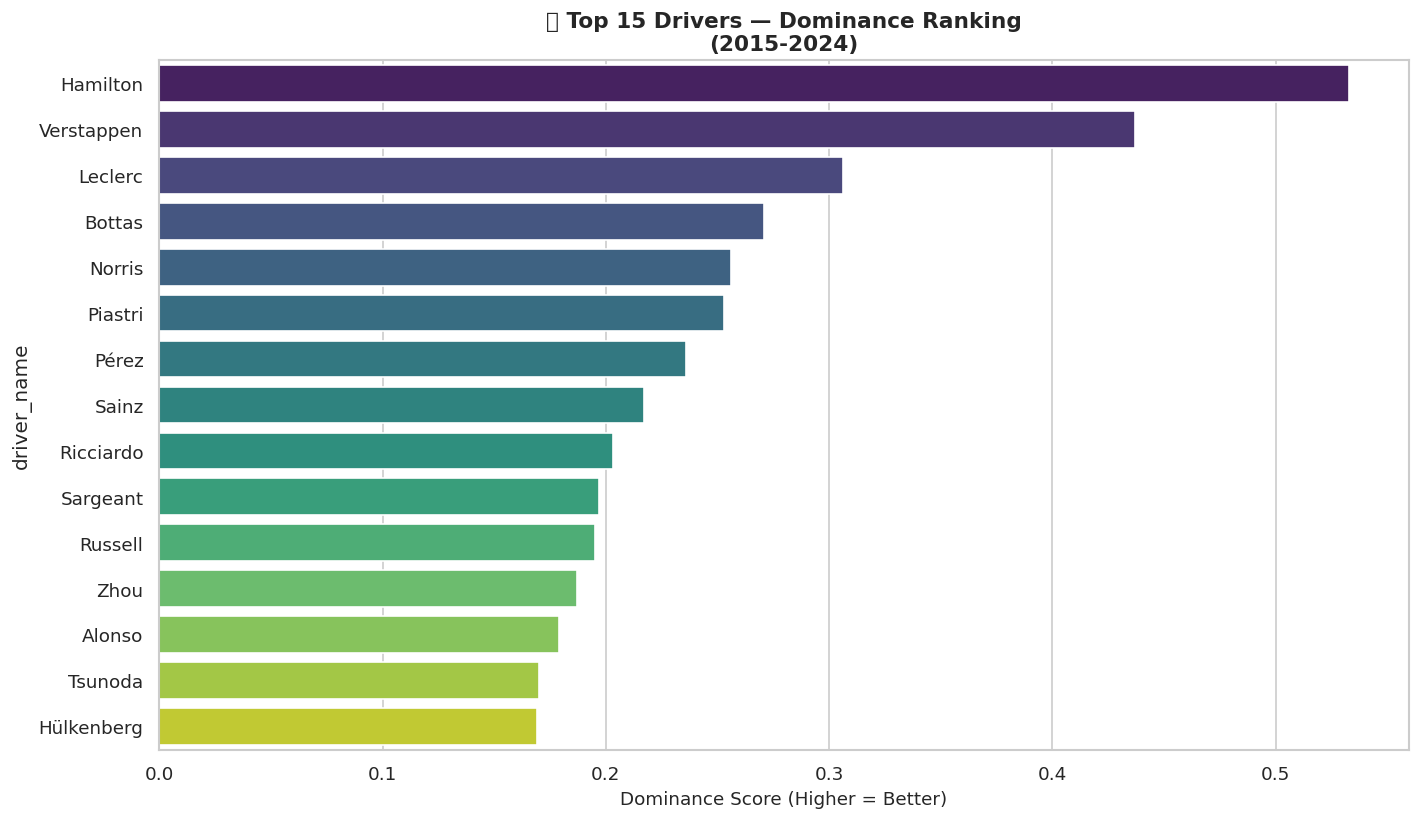

PART 2: BUSINESS VALUE (FOR SPONSORSHIP)

💰 Top 15 Drivers — Business Value for Sponsorship:



,Avg_Podium_Rate,Podium_Consistency,Avg_Season_Points,Business_Value
driver_name,,,,
Hamilton,0.651,0.258,333.450,0.571
Verstappen,0.526,0.294,291.250,0.448
Leclerc,0.279,0.229,194.714,0.330
Hülkenberg,0.000,0.000,36.778,0.322
Gasly,0.030,0.025,53.250,0.322
Ocon,0.024,0.026,55.000,0.319
Tsunoda,0.000,0.000,21.750,0.313
Magnussen,0.000,0.000,15.667,0.309
Zhou,0.000,0.000,5.333,0.303


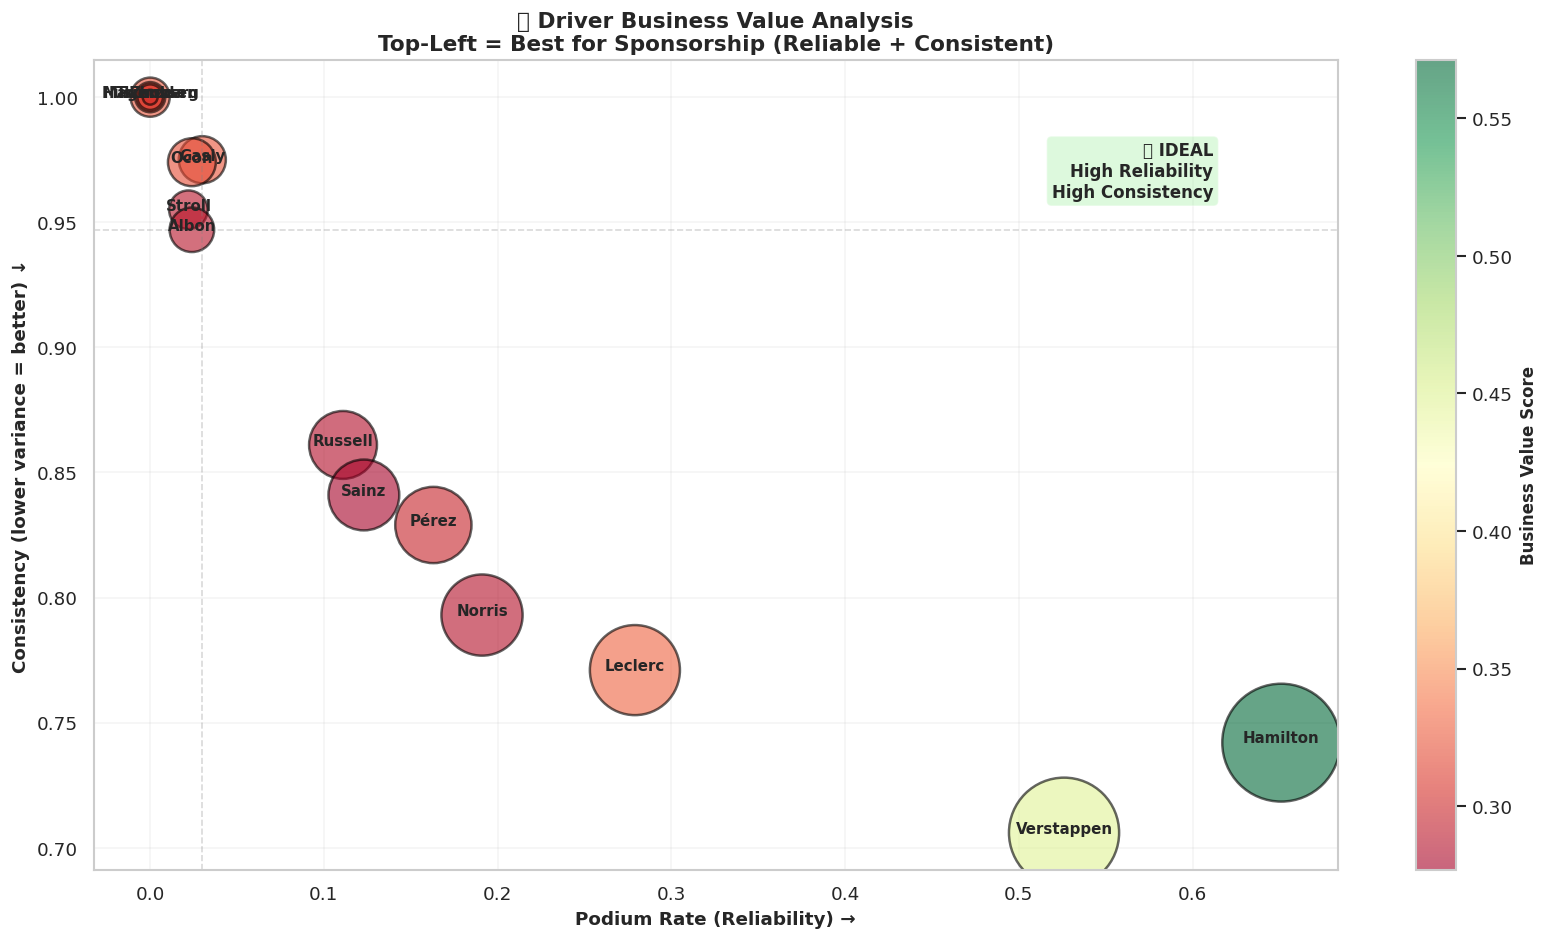

PART 3: DRIVER EFFICIENCY (POINTS PER RACE)

⚡ Top 15 Drivers — Efficiency (Points Per Race):



,Total_Races,Points_Per_Race,Podium_Rate,Efficiency_Score
driver_name,,,,
Hamilton,208,16.03,0.635,0.854
Verstappen,209,13.94,0.536,0.736
Leclerc,149,9.15,0.289,0.458
Bottas,209,7.65,0.292,0.403
Piastri,46,7.54,0.217,0.369
Norris,128,7.42,0.203,0.359
Pérez,207,6.75,0.169,0.320
Sainz,208,5.79,0.130,0.269
Ricciardo,188,5.60,0.128,0.261


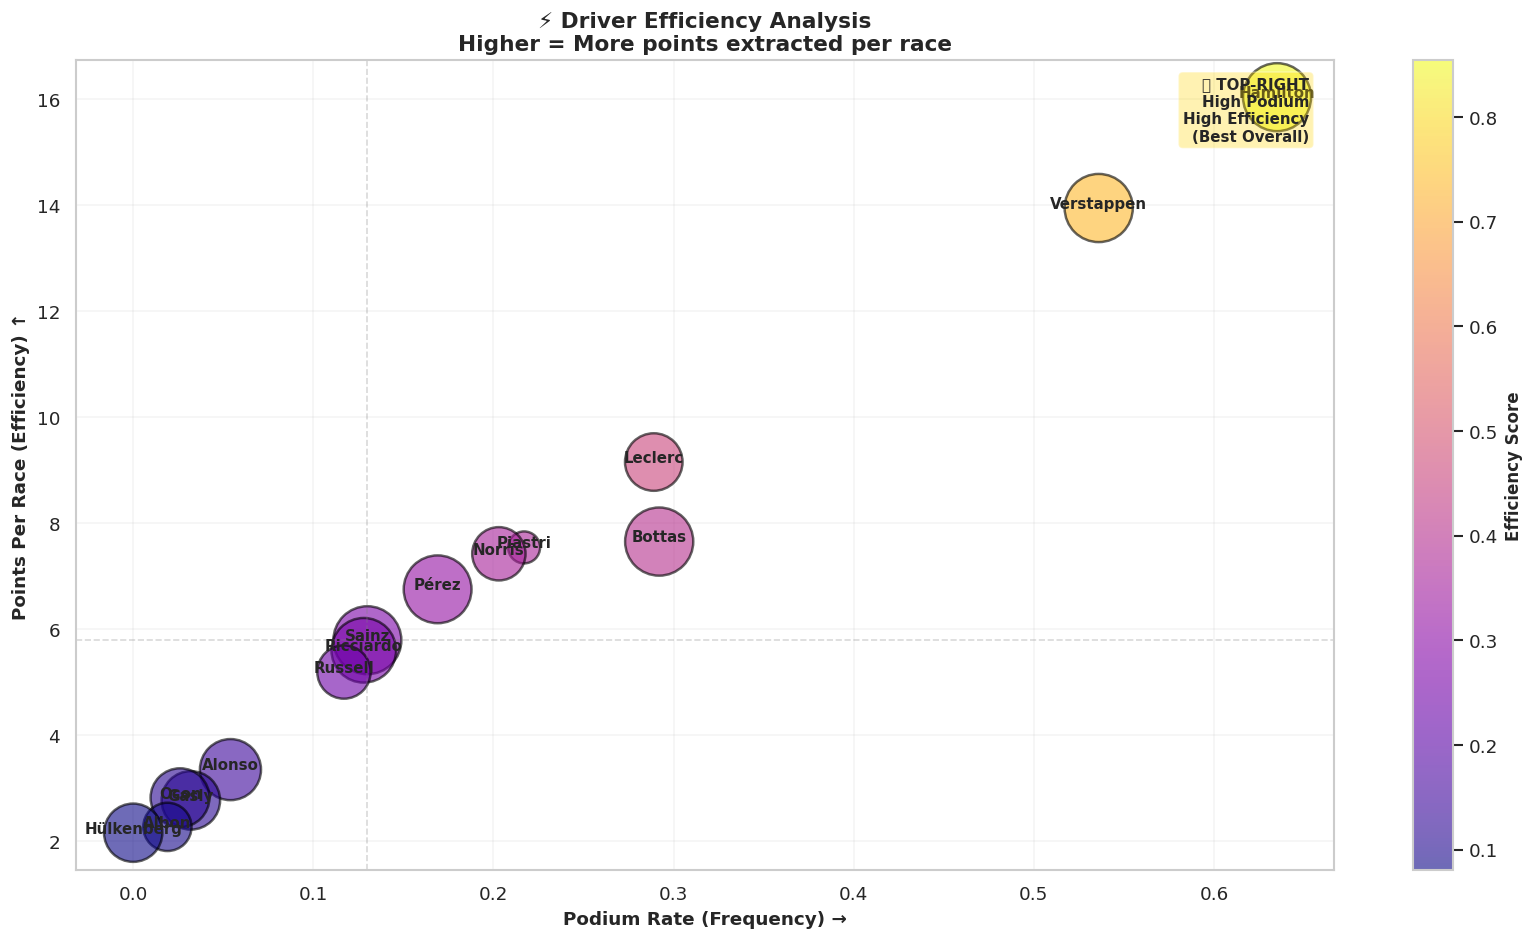

SUMMARY: DRIVER RANKING BY BUSINESS CRITERIA

 RECOMMENDATION FOR DIFFERENT BUSINESS NEEDS:



,Top Dominance,Top Business Value,Top Efficiency
0,Hamilton,Hamilton,Hamilton
1,Verstappen,Verstappen,Verstappen
2,Leclerc,Leclerc,Leclerc
3,Bottas,Hülkenberg,Bottas
4,Norris,Gasly,Piastri



💡 INTERPRETATION:
   • Top Dominance: Siapa driver terbaik secara keseluruhan
   • Top Business Value: Siapa paling bagus untuk sponsorship (reliable + consistent)
   • Top Efficiency: Siapa paling productive per race (extraction optimal)


In [ ]:
# 9. DRIVER ANALYSIS (COMPREHENSIVE)

# Merge driver names
df_with_names = df.merge(drivers[['driverId', 'surname']], on='driverId', how='left')
df_with_names.rename(columns={'surname': 'driver_name'}, inplace=True);

print(' Driver names loaded')

# PART 1: DOMINANCE RANKING
print('PART 1: DRIVER DOMINANCE RANKING')

driver_stats = df_with_names.groupby('driver_name').agg({
    'is_podium': ['sum', 'count', 'mean'],
    'points': ['sum', 'mean', 'std']
}).round(3)

driver_stats.columns = ['Podium_Count', 'Total_Races', 'Podium_Rate',
                        'Total_Points', 'Avg_Points', 'Points_Std']

driver_stats = driver_stats[driver_stats['Total_Races'] >= 20].copy()

driver_stats['Dominance_Score'] = (
    driver_stats['Podium_Rate'] * 0.4 +
    (driver_stats['Avg_Points'] / 25) * 0.4 +
    (1 - driver_stats['Points_Std'] / driver_stats['Points_Std'].max()) * 0.2
).round(3)

driver_ranking = driver_stats.sort_values('Dominance_Score', ascending=False).head(15)

print('\n📊 Top 15 Drivers — Overall Dominance:\n')
display(driver_ranking[['Total_Races', 'Podium_Rate', 'Avg_Points', 'Dominance_Score']])

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=driver_ranking['Dominance_Score'],
            y=driver_ranking.index,
            palette='viridis', ax=ax)
ax.set_title('📊 Top 15 Drivers — Dominance Ranking\n(2015-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dominance Score (Higher = Better)', fontsize=11)
plt.tight_layout()
plt.show()

# PART 2: BUSINESS VALUE (Sponsorship Appeal)
print('PART 2: BUSINESS VALUE (FOR SPONSORSHIP)')

driver_yearly = df_with_names.groupby(['driver_name', 'year']).agg({
    'is_podium': ['sum', 'count'],
    'points': 'sum'
}).reset_index()

driver_yearly.columns = ['driver_name', 'year', 'podium_count', 'race_count', 'season_points']
driver_yearly['podium_rate'] = driver_yearly['podium_count'] / driver_yearly['race_count']

driver_biz = driver_yearly.groupby('driver_name').agg({
    'podium_rate': ['mean', 'std'],
    'season_points': ['mean', 'max'],
    'year': 'count'
}).round(3)

driver_biz.columns = ['Avg_Podium_Rate', 'Podium_Consistency',
                      'Avg_Season_Points', 'Peak_Season_Points', 'Seasons']

driver_biz['Business_Value'] = (
    driver_biz['Avg_Podium_Rate'] * 0.5 +
    (1 - driver_biz['Podium_Consistency'] / driver_biz['Podium_Consistency'].max()) * 0.3 +
    (driver_biz['Avg_Season_Points'] / driver_biz['Avg_Season_Points'].max()) * 0.2
).round(3)

driver_biz = driver_biz[driver_biz['Seasons'] >= 3].sort_values('Business_Value', ascending=False)

print('\n💰 Top 15 Drivers — Business Value for Sponsorship:\n')
display(driver_biz.head(15)[['Avg_Podium_Rate', 'Podium_Consistency', 'Avg_Season_Points', 'Business_Value']])

top_drivers_biz = driver_biz.head(15).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    top_drivers_biz['Avg_Podium_Rate'],
    1 - top_drivers_biz['Podium_Consistency'],
    s=top_drivers_biz['Avg_Season_Points']*15,
    alpha=0.6,
    c=top_drivers_biz['Business_Value'],
    cmap='RdYlGn',
    edgecolor='black',
    linewidth=1.5
)

for idx, row in top_drivers_biz.iterrows():
    ax.annotate(row['driver_name'],
               (row['Avg_Podium_Rate'], 1 - row['Podium_Consistency']),
               fontsize=9, fontweight='bold', ha='center')

ax.set_xlabel('Podium Rate (Reliability) →', fontsize=11, fontweight='bold')
ax.set_ylabel('Consistency (lower variance = better) ↓', fontsize=11, fontweight='bold')
ax.set_title('💰 Driver Business Value Analysis\nTop-Left = Best for Sponsorship (Reliable + Consistent)',
            fontsize=13, fontweight='bold')

# Add quadrant lines
ax.axvline(top_drivers_biz['Avg_Podium_Rate'].median(), color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline((1 - top_drivers_biz['Podium_Consistency']).median(), color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Add text di kuadran
ax.text(0.9, 0.9, '🟢 IDEAL\nHigh Reliability\nHigh Consistency',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3),
        ha='right', va='top')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Business Value Score', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# PART 3: ROI / EFFICIENCY
print('PART 3: DRIVER EFFICIENCY (POINTS PER RACE)')

driver_roi = df_with_names.groupby('driver_name').agg({
    'is_podium': ['sum', 'count'],
    'points': 'sum'
}).round(2)

driver_roi.columns = ['Podium_Count', 'Total_Races', 'Total_Points']

driver_roi['Points_Per_Race'] = (driver_roi['Total_Points'] / driver_roi['Total_Races']).round(2)
driver_roi['Podium_Rate'] = (driver_roi['Podium_Count'] / driver_roi['Total_Races']).round(3)

driver_roi['Efficiency_Score'] = (
    (driver_roi['Points_Per_Race'] / driver_roi['Points_Per_Race'].max()) * 0.6 +
    driver_roi['Podium_Rate'] * 0.4
).round(3)

driver_roi = driver_roi[driver_roi['Total_Races'] >= 15].sort_values('Efficiency_Score', ascending=False)

print('\n⚡ Top 15 Drivers — Efficiency (Points Per Race):\n')
display(driver_roi.head(15)[['Total_Races', 'Points_Per_Race', 'Podium_Rate', 'Efficiency_Score']])

fig, ax = plt.subplots(figsize=(14, 8))
top_roi = driver_roi.head(15).reset_index()

scatter = ax.scatter(
    top_roi['Podium_Rate'],
    top_roi['Points_Per_Race'],
    s=top_roi['Total_Races']*8,
    alpha=0.6,
    c=top_roi['Efficiency_Score'],
    cmap='plasma',
    edgecolor='black',
    linewidth=1.5
)

for idx, row in top_roi.iterrows():
    ax.annotate(row['driver_name'],
               (row['Podium_Rate'], row['Points_Per_Race']),
               fontsize=9, fontweight='bold', ha='center')

ax.set_xlabel('Podium Rate (Frequency) →', fontsize=11, fontweight='bold')
ax.set_ylabel('Points Per Race (Efficiency) ↑', fontsize=11, fontweight='bold')
ax.set_title('⚡ Driver Efficiency Analysis\nHigher = More points extracted per race',
            fontsize=13, fontweight='bold')

# Quadrant analysis
ax.axvline(top_roi['Podium_Rate'].median(), color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(top_roi['Points_Per_Race'].median(), color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax.text(0.98, 0.98, '🏆 TOP-RIGHT\nHigh Podium\nHigh Efficiency\n(Best Overall)',
        transform=ax.transAxes, fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3),
        ha='right', va='top')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Efficiency Score', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# SUMMARY: ACTIONABLE INSIGHTS
print('SUMMARY: DRIVER RANKING BY BUSINESS CRITERIA')

summary_table = pd.DataFrame({
    'Top Dominance': driver_ranking.index[:5].tolist(),
    'Top Business Value': driver_biz.head(5).index.tolist(),
    'Top Efficiency': driver_roi.head(5).index.tolist()
})

print('\n RECOMMENDATION FOR DIFFERENT BUSINESS NEEDS:\n')
display(summary_table)

print('\n💡 INTERPRETATION:')
print('   • Top Dominance: Siapa driver terbaik secara keseluruhan')
print('   • Top Business Value: Siapa paling bagus untuk sponsorship (reliable + consistent)')
print('   • Top Efficiency: Siapa paling productive per race (extraction optimal)')

###  Project Klasifikasi Selesai!

**Summary Kedua Project:**

| Aspek | Regresi | Klasifikasi |
|-------|---------|-------------|
| **Task** | Prediksi nilai poin numerik | Binary: Podium vs Non-Podium |
| **Models** | Linear, Ridge, Tree, RF, XGB | Logistic, DT, RF, GB, XGB, SVM |
| **Metrics** | MAE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC |
| **Class Balance** | N/A | Handled with SMOTE |
| **Best Approach** | Ensemble (RF, XGB) | Ensemble + Probability Calibration |

*Dataset: Formula 1 World Championship | Source: Kaggle (Rohan Rao)*